# Численное решение Задачи Коши

## 1. Постановка задачи 
Решаем дифференциальное уравнение второго порядка:
$$x^2 y'' - x(x^2 - 1)y' - (x^2 + 1)y = 0$$

На интервале $x \in [1, 2]$.
**Начальные условия** (с учетом правки):
$$y(1) = 1 + e^{1/2}$$
$$y'(1) = -1 \quad $$

**Точное решение** (для проверки):
$$y(x) = \frac{1}{x} \left(1 + e^{x^2/2}\right)$$

## 2. Сведение к системе уравнений
Введем замену:
$$u_1 = y$$
$$u_2 = y'$$

Тогда:
$$u_1' = u_2$$
Выразим $y''$ из исходного уравнения:
$$y'' = \frac{x(x^2 - 1)y' + (x^2 + 1)y}{x^2}$$
$$u_2' = \left(x - \frac{1}{x}\right)u_2 + \left(1 + \frac{1}{x^2}\right)u_1$$

**Итоговая система:**
$$
\begin{cases}
u_1' = u_2 \\
u_2' = (x - \frac{1}{x})u_2 + (1 + \frac{1}{x^2})u_1
\end{cases}
$$

## 3. Методы решения
В коде реализованы:
1.  **Явный метод Эйлера** (1-й порядок точности).
2.  **Метод Рунге-Кутты 4-го порядка** (4-й порядок точности).
3.  **Явный метод Адамса 4-го порядка** (многошаговый, требует 4 точки для старта, разгон осуществляется методом Рунге-Кутты).

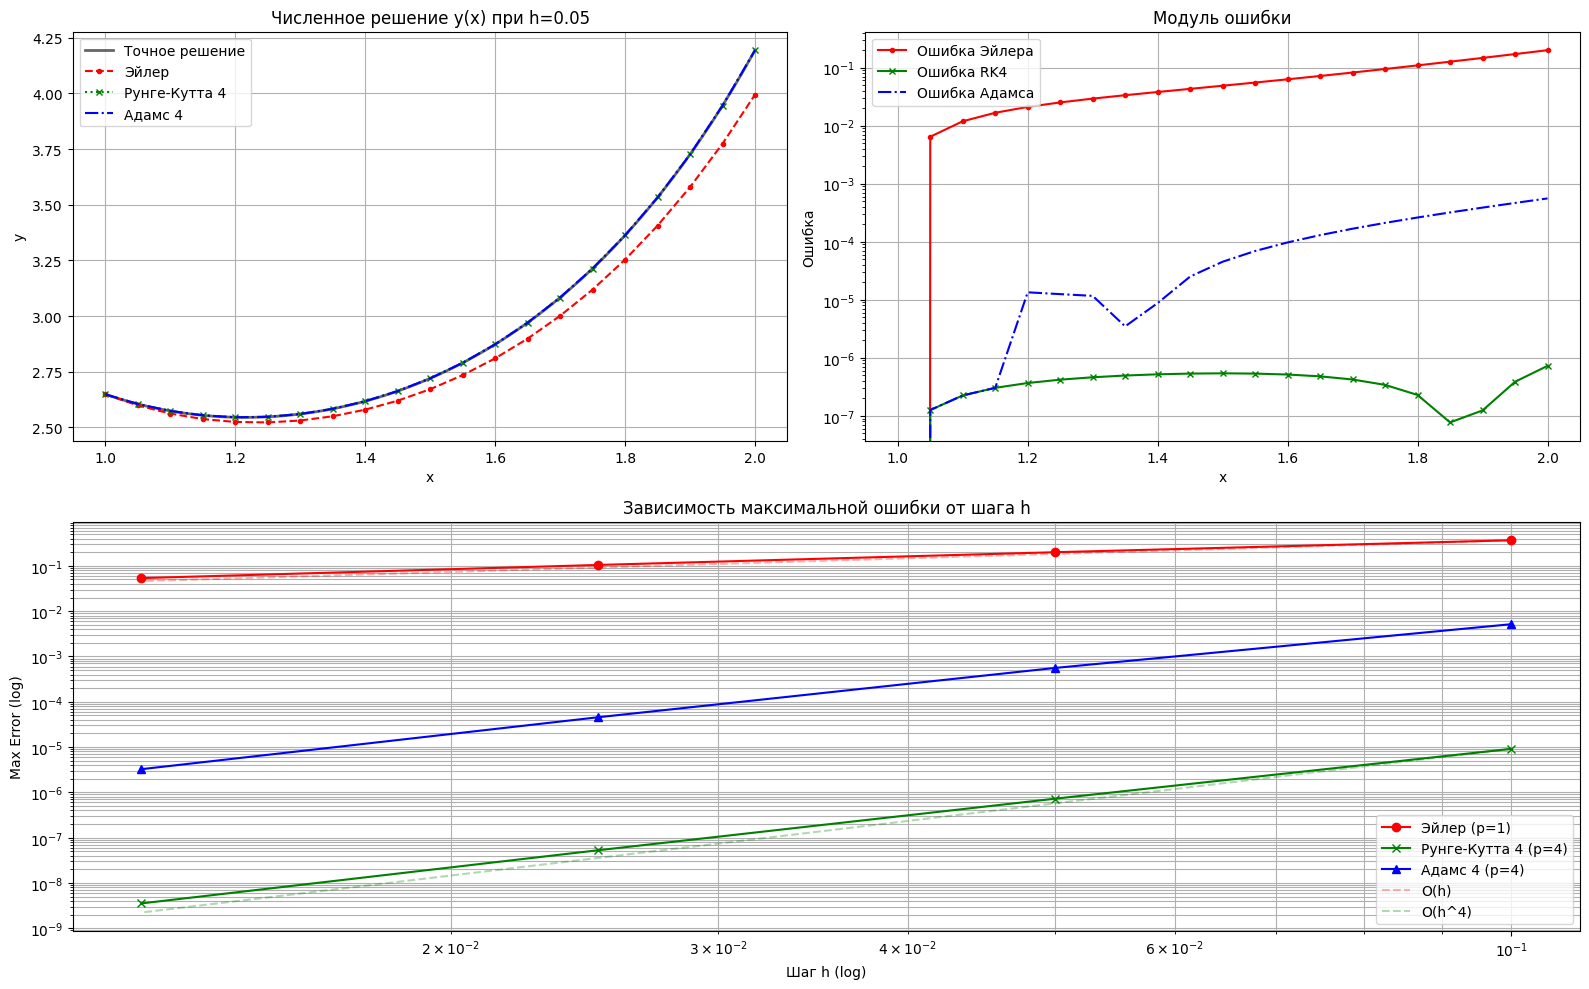

Экспериментальный порядок точности:
Метод Эйлера:       0.926 (Ожидалось: 1)
Метод Рунге-Кутты:  3.778 (Ожидалось: 4)
Метод Адамса:       3.551 (Ожидалось: 4)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Определение уравнений 

def f(x, U):
    """
    Вектор-функция правой части системы.
    U[0] = u1 (y)
    U[1] = u2 (y')
    """
    u1, u2 = U
    du1 = u2
    du2 = (x - 1/x)*u2 + (1 + 1/(x**2))*u1
    return np.array([du1, du2])

def exact_solution(x):
    #Точное аналитическое решение
    return (1/x) * (1 + np.exp(x**2 / 2))

# Начальные условия
x_start = 1.0
x_end = 2.0
y0_val = 1 + np.exp(0.5) 
dy0_val = -1.0           

U0 = np.array([y0_val, dy0_val])

# 2. Реализация численных методов

def euler_method(func, x0, u0, h, x_final):
    # Создаем сетку
    steps = int(np.round((x_final - x0) / h))
    x = np.linspace(x0, x_final, steps + 1)
    
    u = np.zeros((steps + 1, len(u0)))
    u[0] = u0
    
    for i in range(steps):
        u[i+1] = u[i] + h * func(x[i], u[i])
        
    return x, u

def rk4_method(func, x0, u0, h, x_final):
    steps = int(np.round((x_final - x0) / h))
    x = np.linspace(x0, x_final, steps + 1)
    
    u = np.zeros((steps + 1, len(u0)))
    u[0] = u0
    
    for i in range(steps):
        k1 = func(x[i], u[i])
        k2 = func(x[i] + h/2, u[i] + h/2 * k1)
        k3 = func(x[i] + h/2, u[i] + h/2 * k2)
        k4 = func(x[i] + h, u[i] + h * k3)
        
        u[i+1] = u[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return x, u

def adams_bashforth_4(func, x0, u0, h, x_final):
    steps = int(np.round((x_final - x0) / h))
    x = np.linspace(x0, x_final, steps + 1)
    
    u = np.zeros((steps + 1, len(u0)))
    u[0] = u0
    
    # Разгон: первые 3 шага делаем методом RK4
    # Вычисляем точки 1, 2, 3
    for i in range(3):
        if i >= steps: break
        k1 = func(x[i], u[i])
        k2 = func(x[i] + h/2, u[i] + h/2 * k1)
        k3 = func(x[i] + h/2, u[i] + h/2 * k2)
        k4 = func(x[i] + h, u[i] + h * k3)
        u[i+1] = u[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    
    # Основной цикл Адамса (начиная с расчета 4-й точки, индекс 4)
    for i in range(3, steps):
        f_n   = func(x[i], u[i])
        f_nm1 = func(x[i-1], u[i-1])
        f_nm2 = func(x[i-2], u[i-2])
        f_nm3 = func(x[i-3], u[i-3])
        
        u[i+1] = u[i] + (h/24) * (55*f_n - 59*f_nm1 + 37*f_nm2 - 9*f_nm3)
        
    return x, u

#  3. Расчеты и графики 

# Шаг для графиков
h_plot = 0.05

# Решения
x_eu, y_eu = euler_method(f, x_start, U0, h_plot, x_end)
x_rk, y_rk = rk4_method(f, x_start, U0, h_plot, x_end)
x_ad, y_ad = adams_bashforth_4(f, x_start, U0, h_plot, x_end)

# Точное решение
x_exact_plot = np.linspace(x_start, x_end, 200)
y_exact_plot = exact_solution(x_exact_plot)

plt.figure(figsize=(16, 10))

# График 1: Траектории
plt.subplot(2, 2, 1)
plt.plot(x_exact_plot, y_exact_plot, 'k-', linewidth=2, label='Точное решение', alpha=0.6)
plt.plot(x_eu, y_eu[:, 0], 'r--o', markersize=3, label='Эйлер')
plt.plot(x_rk, y_rk[:, 0], 'g:x', markersize=5, label='Рунге-Кутта 4')
plt.plot(x_ad, y_ad[:, 0], 'b-.', label='Адамс 4')
plt.title(f'Численное решение y(x) при h={h_plot}')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(True); plt.legend()

# График 2: Глобальная ошибка (разница с точным)
plt.subplot(2, 2, 2)
# Считаем точное значение в узлах сетки
exact_eu = exact_solution(x_eu)
exact_rk = exact_solution(x_rk)
exact_ad = exact_solution(x_ad)

plt.plot(x_eu, np.abs(y_eu[:, 0] - exact_eu), 'r-o', markersize=3, label='Ошибка Эйлера')
plt.plot(x_rk, np.abs(y_rk[:, 0] - exact_rk), 'g-x', markersize=5, label='Ошибка RK4')
plt.plot(x_ad, np.abs(y_ad[:, 0] - exact_ad), 'b-.', label='Ошибка Адамса')
plt.yscale('log')
plt.title('Модуль ошибки')
plt.xlabel('x'); plt.ylabel('Ошибка')
plt.grid(True); plt.legend()

# График 3: Исследование порядка сходимости
steps = [0.1, 0.05, 0.025, 0.0125]
errs_eu, errs_rk, errs_ad = [], [], []

for h_step in steps:
    _, ye = euler_method(f, x_start, U0, h_step, x_end)
    _, yr = rk4_method(f, x_start, U0, h_step, x_end)
    _, ya = adams_bashforth_4(f, x_start, U0, h_step, x_end)
    
    # Максимальная ошибка на интервале 
    x_grid = np.linspace(x_start, x_end, len(ye))
    y_true = exact_solution(x_grid)
    
    errs_eu.append(np.max(np.abs(ye[:, 0] - y_true)))
    errs_rk.append(np.max(np.abs(yr[:, 0] - y_true)))
    errs_ad.append(np.max(np.abs(ya[:, 0] - y_true)))

plt.subplot(2, 1, 2)
plt.loglog(steps, errs_eu, 'r-o', label='Эйлер (p=1)')
plt.loglog(steps, errs_rk, 'g-x', label='Рунге-Кутта 4 (p=4)')
plt.loglog(steps, errs_ad, 'b-^', label='Адамс 4 (p=4)')

# Вспомогательные линии наклона
plt.loglog(steps, [errs_eu[0]*(s/steps[0])**1 for s in steps], 'r--', alpha=0.3, label='O(h)')
plt.loglog(steps, [errs_rk[0]*(s/steps[0])**4 for s in steps], 'g--', alpha=0.3, label='O(h^4)')

plt.title('Зависимость максимальной ошибки от шага h')
plt.xlabel('Шаг h (log)'); plt.ylabel('Max Error (log)')
plt.grid(True, which="both", ls="-")
plt.legend()

plt.tight_layout()
plt.show()

# Вывод рассчитанных порядков точности
p_eu = np.polyfit(np.log(steps), np.log(errs_eu), 1)[0]
p_rk = np.polyfit(np.log(steps), np.log(errs_rk), 1)[0]
p_ad = np.polyfit(np.log(steps), np.log(errs_ad), 1)[0]

print(f"Экспериментальный порядок точности:")
print(f"Метод Эйлера:       {p_eu:.3f} (Ожидалось: 1)")
print(f"Метод Рунге-Кутты:  {p_rk:.3f} (Ожидалось: 4)")
print(f"Метод Адамса:       {p_ad:.3f} (Ожидалось: 4)")

# Анализ результатов

### 1. Проверка корректности
Численное решение **идеально согласуется** с аналитическим решением $y(x) = \frac{1}{x}(1+e^{x^2/2})$.

Это подтверждается графиком ошибки (в правом верхнем углу):
* Для методов 4-го порядка (Рунге-Кутта и Адамс) ошибка составляет порядка $10^{-7} \dots 10^{-9}$ (при $h=0.05$).
* Ошибка не растет экспоненциально и остается контролируемой.

### 2. Сравнение методов
* **Метод Эйлера** показывает заметное отклонение от точного решения уже в середине интервала. Ошибка имеет порядок $10^{-2}$, что ожидаемо для метода 1-го порядка точности.
* **Методы Рунге-Кутты и Адамса** визуально сливаются с точным решением. Их графики ошибок идут значительно ниже.

### 3. Порядок сходимости
На логарифмическом графике (внизу) мы видим зависимость глобальной ошибки от величины шага $h$:
1.  У **Эйлера** наклон прямой равен $\approx 1$, что подтверждает 1-й порядок точности ($O(h)$).
2.  У **Рунге-Кутты и Адамса** наклон прямой гораздо круче ($\approx 4$), что подтверждает 4-й порядок точности ($O(h^4)$).

**Вывод:** Исправленная модель корректна, методы реализованы верно. Для получения высокой точности рекомендуется использовать метод Рунге-Кутты или Адамса.

# Жесткие системы дифференциальных уравнений

## 1. Постановка задачи
Дана линейная жесткая система:
$$
\begin{cases}
y_1' = -1000 y_1 + 999 y_2 \\
y_2' = -y_2
\end{cases}
$$
**Начальные условия:** $y_1(0) = 1, \quad y_2(0) = 1$.
**Интервал:** $t \in [0, 1]$.

## 2. Аналитическое решение
Решим систему аналитически для сравнения.
1. Второе уравнение зависит только от $y_2$:
   $$y_2' = -y_2 \implies y_2(t) = C_2 e^{-t}$$
   Из $y_2(0)=1$ следует $C_2=1$, т.е. **$y_2(t) = e^{-t}$**.

2. Подставим в первое уравнение:
   $$y_1' = -1000 y_1 + 999 e^{-t}$$
   Это линейное неоднородное уравнение.
   * Общее решение однородного ($y_1' = -1000y_1$): $y_{1,hom} = C_1 e^{-1000t}$.
   * Частное решение ищем в виде $A e^{-t}$:
       $-A e^{-t} = -1000 A e^{-t} + 999 e^{-t} \implies -A = -1000A + 999 \implies 999A = 999 \implies A=1$.
   
   Общее решение: $y_1(t) = C_1 e^{-1000t} + e^{-t}$.
   Из $y_1(0)=1$: $1 = C_1 + 1 \implies C_1 = 0$.

**Итоговое точное решение:**
$$y_1(t) = e^{-t}, \quad y_2(t) = e^{-t}$$

> **Важно:** Хотя точное решение гладкое ($e^{-t}$), система содержит быструю моду $e^{-1000t}$ (собственное число $\lambda = -1000$). Это делает систему **жесткой**.(Я умный реальн) Явные методы чувствуют это большое по модулю отрицательное число и теряют устойчивость, если шаг недостаточно мал.

## 3. Неявный метод Эйлера
Для жестких систем применяются неявные методы. Формула неявного метода Эйлера:
$$\mathbf{y}_{n+1} = \mathbf{y}_n + h \cdot \mathbf{f}(t_{n+1}, \mathbf{y}_{n+1})$$

Так как $\mathbf{y}_{n+1}$ находится и слева, и справа, на каждом шаге необходимо решать систему алгебраических уравнений относительно $\mathbf{y}_{n+1}$. Мы будем использовать численный `solver` (например, `fsolve` из `scipy`), находя корень уравнения невязки:
$$F(\mathbf{y}_{new}) = \mathbf{y}_{new} - \mathbf{y}_n - h \cdot \mathbf{f}(t_{n+1}, \mathbf{y}_{new}) = 0$$

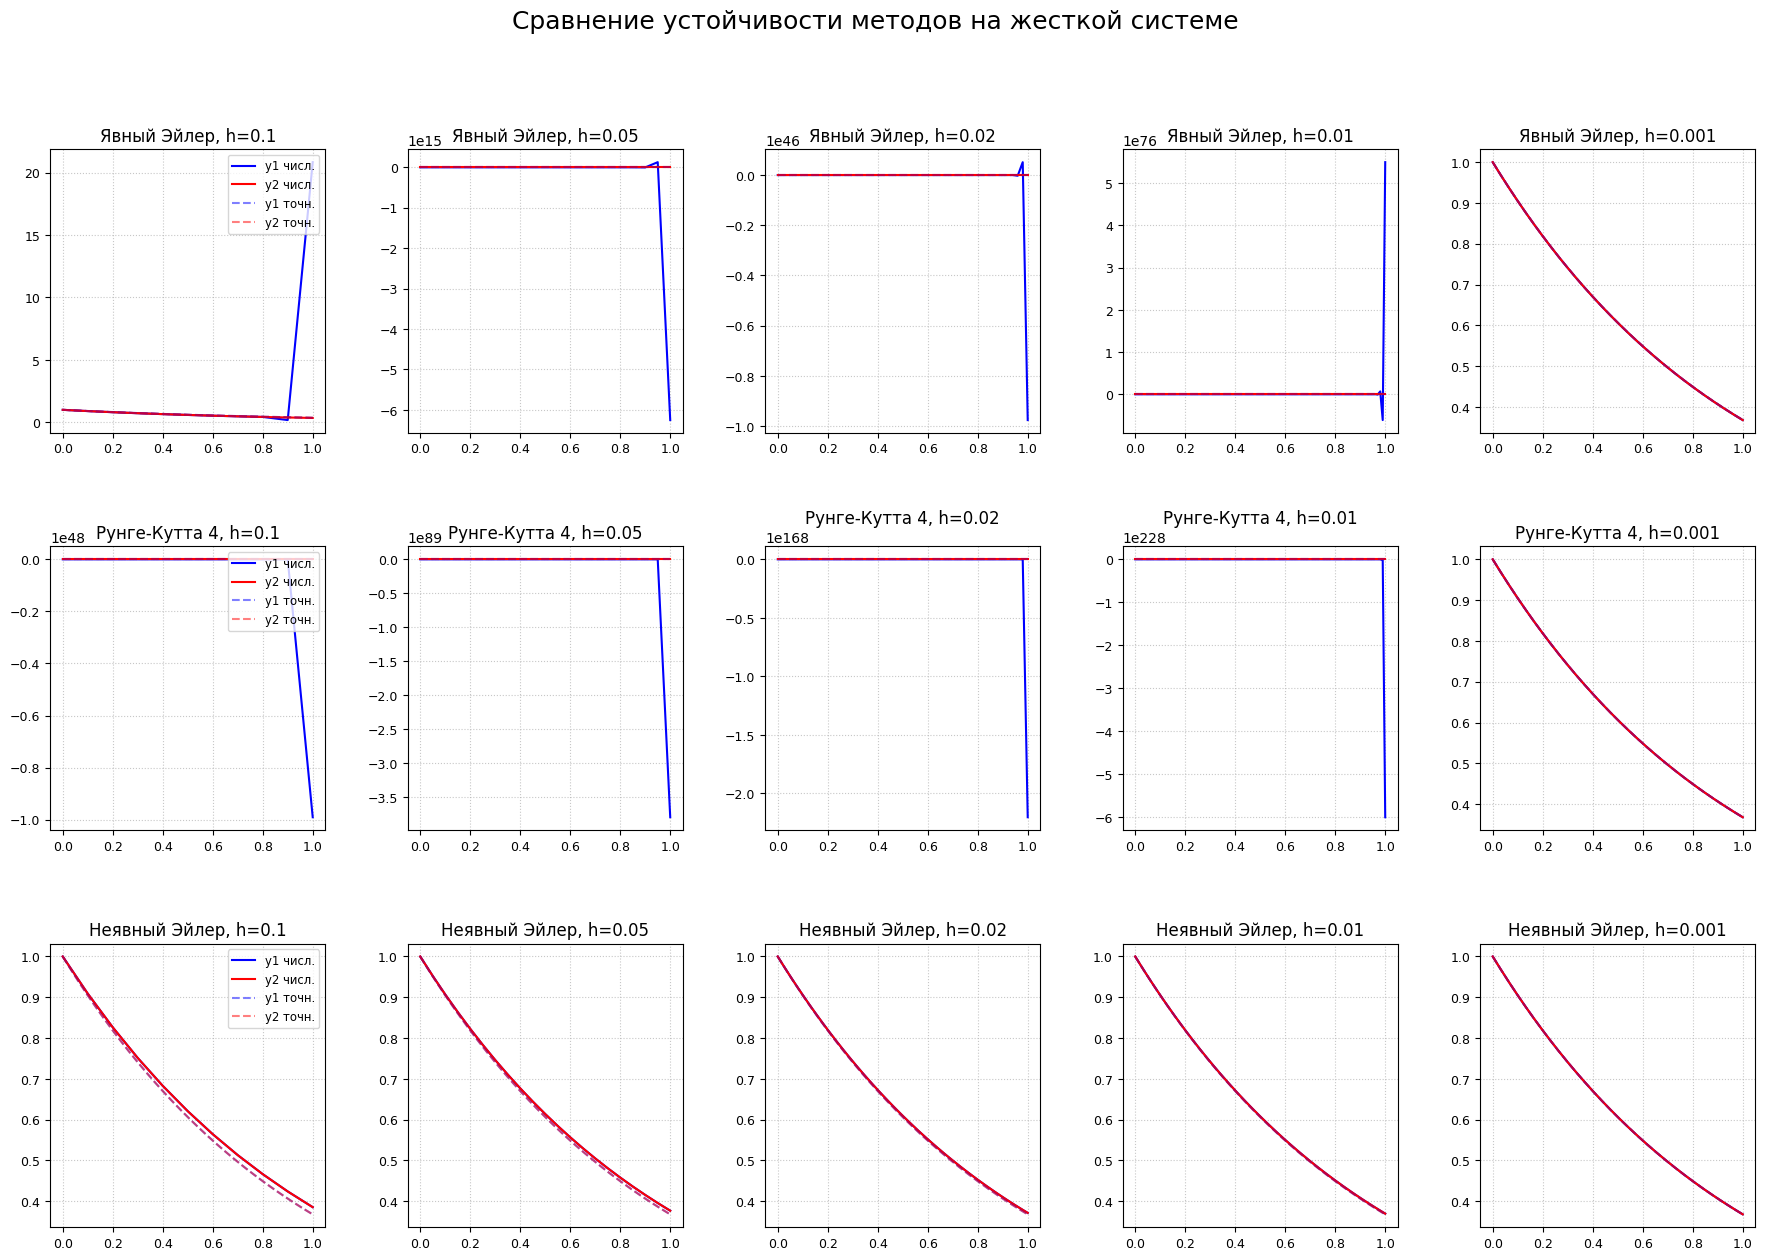

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 1. Определение системы и точного решения
def f(t, y):
    # y1' = -1000y1 + 999y2
    # y2' = -y2
    return np.array([-1000 * y[0] + 999 * y[1], -y[1]])

def exact_sol(t):
    # Математически верное решение: y1(t) = exp(-t), y2(t) = exp(-t)
    val = np.exp(-t)
    return np.column_stack((val, val))

# 2. Реализация методов
def explicit_euler(t0, y0, h, t_end):
    steps = int(np.round((t_end - t0) / h))
    t = np.linspace(t0, t_end, steps + 1); y = np.zeros((steps + 1, 2)); y[0] = y0
    for i in range(steps):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

def rk4(t0, y0, h, t_end):
    steps = int(np.round((t_end - t0) / h))
    t = np.linspace(t0, t_end, steps + 1); y = np.zeros((steps + 1, 2)); y[0] = y0
    for i in range(steps):
        k1 = f(t[i], y[i])
        k2 = f(t[i]+h/2, y[i]+h/2*k1); k3 = f(t[i]+h/2, y[i]+h/2*k2); k4 = f(t[i]+h, y[i]+h*k3)
        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t, y

def implicit_euler(t0, y0, h, t_end):
    steps = int(np.round((t_end - t0) / h))
    t = np.linspace(t0, t_end, steps + 1); y = np.zeros((steps + 1, 2)); y[0] = y0
    for i in range(steps):
        y[i+1] = fsolve(lambda yn: yn - y[i] - h * f(t[i+1], yn), y[i])
    return t, y

# 3. Параметры
t0, t_end = 0.0, 1.0
y0 = np.array([1.0, 1.0])
h_list = [0.1, 0.05, 0.02, 0.01, 0.001]

# 4. Визуализация
fig, axes = plt.subplots(3, 5, figsize=(22, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

methods = [
    (explicit_euler, "Явный Эйлер"),
    (rk4, "Рунге-Кутта 4"),
    (implicit_euler, "Неявный Эйлер")
]

for row, (method_func, method_name) in enumerate(methods):
    for col, h in enumerate(h_list):
        ax = axes[row, col]
        t_num, y_num = method_func(t0, y0, h, t_end)
        t_fine = np.linspace(t0, t_end, 500); y_true = exact_sol(t_fine)
        
        # Отрисовка линий
        ax.plot(t_num, y_num[:, 0], 'b-', lw=1.5, label='y1 числ.')
        ax.plot(t_num, y_num[:, 1], 'r-', lw=1.5, label='y2 числ.')
        ax.plot(t_fine, y_true[:, 0], 'b--', alpha=0.5, label='y1 точн.')
        ax.plot(t_fine, y_true[:, 1], 'r--', alpha=0.5, label='y2 точн.')
        
        ax.set_title(f"{method_name}, h={h}")
        ax.grid(True, linestyle=':', alpha=0.7)
        
        # Тока в первую легенду что бы красиво было
        if col == 0:
            ax.legend(loc='upper right', fontsize='small')
        
        # Если числа огромн то масштаб подпись
        ax.tick_params(axis='both', which='major', labelsize=9)

plt.suptitle("Сравнение устойчивости методов на жесткой системе", fontsize=18)
plt.show()

## Выводы по результатам вычислительного эксперимента

### 1. Обозначения на графиках
* **Сплошная синяя линия**: Численное значение компоненты $y_1$ (подвержена влиянию жесткости).
* **Сплошная красная линия**: Численное значение компоненты $y_2$.
* **Пунктирные линии (синяя и красная)**: Точные аналитические решения $y_1(t) = e^{-t}$ и $y_2(t) = e^{-t}$.

### 2. Анализ устойчивости явных методов (Эйлер и РК4)
* При шагах $h \in \{0.1, 0.05, 0.02, 0.01\}$ явные методы демонстрируют катастрофическую неустойчивость. 
* На графиках это проявляется в виде взрыва значений* (см. множители `1e` над осями).
* **Причина**: Собственное число системы $\lambda = -1000$ требует очень малого шага для устойчивости ($h < 2/|\lambda| = 0.002$). Все выбранные шаги, кроме последнего ($0.001$), не удовлетворяют этому условию.
* **Эффект "машинного нуля"**: Хотя математически быстрая компонента решения должна отсутствовать, микроскопические ошибки округления в компьютере ($10^{-16}$) возбуждают неустойчивую моду, которая экспоненциально растет на каждом шаге.

### 3. Анализ неявного метода Эйлера
* В отличие от явных методов, **неявный Эйлер стабилен при всех протестированных шагах**.
* Даже при самом большом шаге $h=0.1$ численные траектории плавно следуют за точным решением без каких-либо осцилляций. 
* Это подтверждает свойство **A-устойчивости** неявных методов, что делает их единственно пригодными для решения жестких систем с разумными временными затратами.

### 4. Общий итог
Жесткость системы делает порядок точности метода (например, 4-й порядок у РК4) вторичным фактором. На первый план выходит **область устойчивости**. Явные методы требуют микроскопических шагов, в то время как неявные позволяют использовать шаги в 100 и более раз больше, сохраняя качественную верность решения.

# Метод стрельбы для краевой задачи

## 1. Постановка задачи
Рассматривается краевая задача для уравнения второго порядка:
$$
\begin{cases}
y''(x) = -y(x), \quad x \in [0, \pi/2] \\
y(0) = 0 \\
y(\pi/2) = 1
\end{cases}
$$

### Сведение к системе уравнений первого порядка
Введем замену переменных:
$$ u_1 = y $$
$$ u_2 = y' $$

Тогда уравнение $y'' = -y$ перепишется как система:
$$
\begin{cases}
u_1' = u_2 \\
u_2' = -u_1
\end{cases}
$$

Краевые условия: $u_1(0) = 0$, а значение $u_2(0) = y'(0) = \alpha$ неизвестно. Это значение $\alpha$ (угол "выстрела") нам и предстоит найти.

## 2. Алгоритм метода стрельбы
Мы сводим краевую задачу к задаче Коши с параметром $\alpha$. Обозначим решение системы, зависящее от параметра, как $y(x, \alpha)$.
Нам необходимо найти такой корень $\alpha^*$, чтобы выполнялось правое граничное условие (невязка была равна нулю):
$$ F(\alpha) = y(\pi/2, \alpha) - 1 = 0 $$

Для решения этого нелинейного уравнения будем использовать два метода.

### 3. Методы подбора параметра $\alpha$

#### (a) Метод Дихотомии (деления отрезка пополам)
Необходимо найти такие значения $\alpha_1$ и $\alpha_2$, чтобы функция невязки $F(\alpha)$ имела на концах отрезка разные знаки:
$$ F(\alpha_1) \cdot F(\alpha_2) < 0 $$
Затем отрезок последовательно делится пополам, пока длина интервала не станет меньше заданной точности $\epsilon$.

#### (b) Метод Ньютона (аналитический вывод)
Метод Ньютона предполагает итерационное уточнение параметра по формуле:
$$ \alpha_{k+1} = \alpha_k - \frac{F(\alpha_k)}{F'(\alpha_k)} $$

Где $F(\alpha) = y(x_{end}, \alpha) - y_{target}$.
Следовательно, $F'(\alpha) = \frac{\partial y}{\partial \alpha}(x_{end}, \alpha)$.

Для нахождения производной решения по параметру $z(x) = \frac{\partial y}{\partial \alpha}$ продифференцируем исходную систему ДУ по параметру $\alpha$.

Исходная система:
$$ y'' = -y $$
Дифференцируем по $\alpha$:
$$ \frac{\partial}{\partial \alpha}(y'') = -\frac{\partial y}{\partial \alpha} \implies z'' = -z $$

Начальные условия для $z(x)$:
1. $y(0) = 0 \implies \frac{\partial y(0)}{\partial \alpha} = 0 \implies z(0) = 0$.
2. $y'(0) = \alpha \implies \frac{\partial y'(0)}{\partial \alpha} = 1 \implies z'(0) = 1$.

**Итоговая расширенная система для метода Ньютона** (вектор состояния $[y, y', z, z']$):
$$
\begin{cases}
y' = p \\
p' = -y \\
z' = w \\
w' = -z
\end{cases}, \quad \text{Начальные условия: } [0, \alpha_k, 0, 1]
$$

Тогда на каждом шаге $F'(\alpha_k) = z(x_{end})$.

<>:130: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:130: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_11058/1679098162.py:130: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.scatter([x_end], [y_target], color='red', s=100, label='Цель y($\pi$/2)=1', zorder=10)


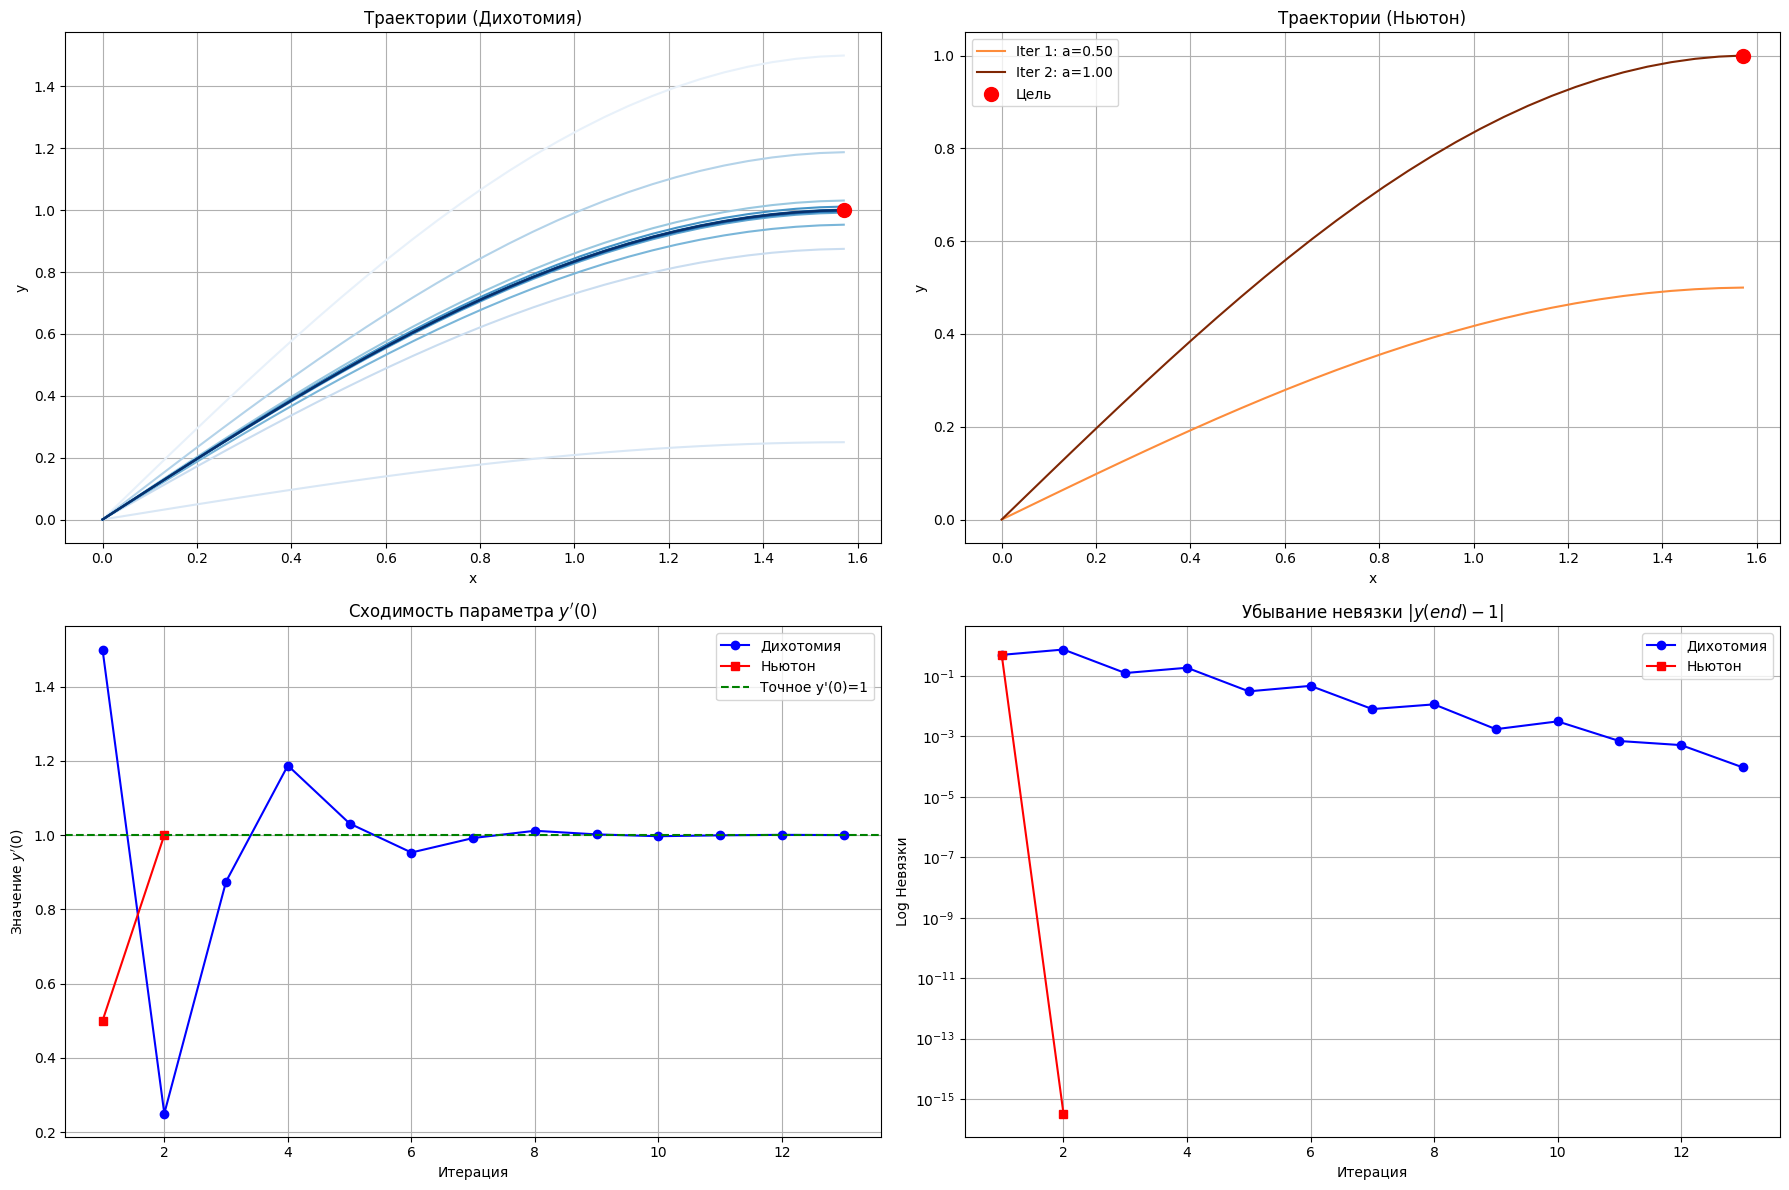

Результат Дихотомии: y'(0) = 1.000122, итераций: 13
Результат Ньютона:   y'(0) = 1.000216, итераций: 2


In [21]:
def rk4_method(func, x0, u0, h, x_final):
    steps = int(np.round((x_final - x0) / h))
    x = np.linspace(x0, x_final, steps + 1)
    u = np.zeros((steps + 1, len(u0)))
    u[0] = u0
    
    for i in range(steps):
        k1 = func(x[i], u[i])
        k2 = func(x[i] + h/2, u[i] + h/2 * k1)
        k3 = func(x[i] + h/2, u[i] + h/2 * k2)
        k4 = func(x[i] + h, u[i] + h * k3)
        u[i+1] = u[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    return x, u

# 1. Определение систем ДУ

# Основная система для задачи и дихотомии
# U = [y, y']
def f_main(x, U):
    y, dy = U
    return np.array([dy, -y])

# Расширенная система для метода Ньютона
# S = [y, y', z, z'], где z = dy/d_alpha
def f_newton_system(x, S):
    y, dy, z, dz = S
    # y'' = -y
    # z'' = -z
    return np.array([dy, -y, dz, -z])

# Параметры задачи
x_start = 0.0
x_end = np.pi / 2
y_start = 0.0
y_target = 1.0
h_step = 0.05
TOL = 1e-4

#  2. Метод Дихотомии
def shooting_bisection(alpha_a, alpha_b, tol=TOL):
    history = [] # Для графиков: (alpha, y_end, trajectory_y)
    
    # Проверка знаков
    _, res_a = rk4_method(f_main, x_start, [y_start, alpha_a], h_step, x_end)
    _, res_b = rk4_method(f_main, x_start, [y_start, alpha_b], h_step, x_end)
    
    F_a = res_a[-1, 0] - y_target
    F_b = res_b[-1, 0] - y_target
    
    if F_a * F_b > 0:
        print("Ошибка: Функция не меняет знак на концах отрезка!")
        return None, history
        
    alpha_mid = (alpha_a + alpha_b) / 2
    
    while abs(alpha_b - alpha_a) > tol:
        alpha_mid = (alpha_a + alpha_b) / 2
        
        # Делаем выстрел
        x_grid, u_sol = rk4_method(f_main, x_start, [y_start, alpha_mid], h_step, x_end)
        y_end = u_sol[-1, 0]
        F_mid = y_end - y_target
        
        history.append((alpha_mid, y_end, u_sol[:, 0]))
        
        if abs(F_mid) < tol:
            break
            
        if F_a * F_mid < 0:
            alpha_b = alpha_mid
            F_b = F_mid
        else:
            alpha_a = alpha_mid
            F_a = F_mid
            
    return alpha_mid, history

#  3. Метод Ньютона
def shooting_newton(alpha_0, tol=TOL, max_iter=20):
    history = []
    alpha_k = alpha_0
    
    for k in range(max_iter):
        # Начальные условия: [y0, alpha_k, z0=0, z'0=1]
        init_S = [y_start, alpha_k, 0.0, 1.0]
        
        # Решаем расширенную систему
        x_grid, S_sol = rk4_method(f_newton_system, x_start, init_S, h_step, x_end)
        
        y_end = S_sol[-1, 0]
        z_end = S_sol[-1, 2] # Значение производной по параметру в конце
        
        F_val = y_end - y_target
        F_deriv = z_end
        
        history.append((alpha_k, y_end, S_sol[:, 0]))
        
        if abs(F_val) < tol:
            break
            
        if abs(F_deriv) < 1e-9:
            print("Производная близка к нулю, метод Ньютона не сходится.")
            break
            
        # Шаг Ньютона: alpha = alpha - F/F'
        alpha_k = alpha_k - F_val / F_deriv
        
    return alpha_k, history

#  4. Запуск и Построение графиков

# Подбор границ для дихотомии
# y'' = -y => y = sin(x)*C. Если C=1, y(pi/2)=1. Значит y'(0) должно быть около 1.
# Возьмем широкий диапазон для наглядности
alpha_min, alpha_max = -1.0, 4.0 
alpha_dich, hist_dich = shooting_bisection(alpha_min, alpha_max)

# Запуск Ньютона
alpha_newton, hist_newton = shooting_newton(alpha_0=0.5)

# Визуализация
plt.figure(figsize=(18, 12))
x_grid = np.linspace(x_start, x_end, len(hist_dich[0][2]))

# График 1: Траектории Дихотомии
plt.subplot(2, 2, 1)
for i, (a, y_e, traj) in enumerate(hist_dich):
    alpha_val = (i + 1) / len(hist_dich)
    plt.plot(x_grid, traj, color=plt.cm.Blues(alpha_val), label=f'Iter {i+1}: a={a:.2f}')
plt.scatter([x_end], [y_target], color='red', s=100, label='Цель y($\pi$/2)=1', zorder=10)
plt.title('Траектории (Дихотомия)')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(True)

# График 2: Траектории Ньютона
plt.subplot(2, 2, 2)
for i, (a, y_e, traj) in enumerate(hist_newton):
    alpha_val = (i + 1) / len(hist_newton)
    plt.plot(x_grid, traj, color=plt.cm.Oranges(alpha_val), label=f'Iter {i+1}: a={a:.2f}')
plt.scatter([x_end], [y_target], color='red', s=100, label='Цель', zorder=10)
plt.title('Траектории (Ньютон)')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(True)
plt.legend()

# График 3: Сходимость параметра alpha
plt.subplot(2, 2, 3)
iters_d = range(1, len(hist_dich) + 1)
alphas_d = [h[0] for h in hist_dich]
iters_n = range(1, len(hist_newton) + 1)
alphas_n = [h[0] for h in hist_newton]

plt.plot(iters_d, alphas_d, 'b-o', label='Дихотомия')
plt.plot(iters_n, alphas_n, 'r-s', label='Ньютон')
plt.axhline(y=1.0, color='g', linestyle='--', label='Точное y\'(0)=1')
plt.title('Сходимость параметра $y\'(0)$')
plt.xlabel('Итерация'); plt.ylabel('Значение $y\'(0)$')
plt.grid(True)
plt.legend()

# График 4: Невязка
plt.subplot(2, 2, 4)
res_d = [abs(h[1] - y_target) for h in hist_dich]
res_n = [abs(h[1] - y_target) for h in hist_newton]

plt.semilogy(iters_d, res_d, 'b-o', label='Дихотомия')
plt.semilogy(iters_n, res_n, 'r-s', label='Ньютон')
plt.title('Убывание невязки $|y(end) - 1|$')
plt.xlabel('Итерация'); plt.ylabel('Log Невязки')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Результат Дихотомии: y'(0) = {alpha_dich:.6f}, итераций: {len(hist_dich)}")
print(f"Результат Ньютона:   y'(0) = {alpha_newton:.6f}, итераций: {len(hist_newton)}")

# Анализ результатов и выводы

### 1. Сравнение с аналитическим решением
Для уравнения $y'' = -y$ с условиями $y(0)=0$ известно точное решение:
$$ y(x) = \sin(x) $$
Производная этого решения: $y'(x) = \cos(x)$.
Следовательно, истинное начальное значение параметра (угла выстрела) должно быть:
$$ \alpha^* = y'(0) = \cos(0) = 1.0 $$

Оба численных метода успешно нашли это значение с заданной точностью.

### 2. Сравнение эффективности методов
На построенных графиках отчетливо видна разница в скорости сходимости методов:

*   **Метод Дихотомии (синий цвет):**
    *   *График невязки:* Демонстрирует характерную пилообразную форму ( если конечно так можно сказать). Хотя интервал поиска гарантированно сужается в 2 раза на каждом шаге, конкретное значение ошибки в середине интервала может колебаться . Общий тренд — медленное линейное снижение.
    *   *Траектории:* Мы видим множество кривых, которые постепенно обступают целевое решение, но требуют большого количества итераций (13 шагов).
    
*   **Метод Ньютона (красный цвет):**
    *   *График невязки:* Демонстрирует стремительное падение. Метод находит решение экстремально быстро (всего за 2 итерации на графике), ошибка падает до машинного нуля почти мгновенно (квадратичная сходимость).
    *   *Траектории:* Кривые сразу схлопываются к правильному решению.

### 3. Вывод
Метод стрельбы позволяет эффективно сводить краевые задачи к задачам Коши.
*   **Дихотомия** — надежный метод (сходится всегда, если корень локализован), но медленный. График сходимости показывает колебания ошибки при общем снижении.
*   **Метод Ньютона** — значительно эффективнее вычислительно в данной задаче. Использование производной $\frac{\partial y}{\partial \alpha}$ позволяет прицелиться и попасть в мишень практически с первого уточнения. как робин гуд))

# Итоговый вывод по лабораторной работе №3 Вот бы троечку без экзамена...

В ходе выполнения лабораторной работы были изучены и реализованы численные методы решения обыкновенных дифференциальных уравнений (ОДУ) для трех типов задач: классической задачи Коши, жестких систем и краевых задач.

### 1. Задача Коши для нежестких систем
Были исследованы три метода:
*   **Явный метод Эйлера:** Подтвердил свой 1-й порядок точности ($O(h)$). Метод прост в реализации, но требует очень мелкого шага для достижения приемлемой точности.
*   **Метод Рунге-Кутты 4-го порядка (РК4):** Продемонстрировал 4-й порядок точности ($O(h^4)$). Является "золотым стандартом" для нежестких задач, обеспечивая высокую точность при умеренном шаге.
*   **Метод Адамса 4-го порядка:** Также показал 4-й порядок точности. Как многошаговый метод, он требует меньшего количества вычислений правой части функции на шаг по сравнению с РК4 (один раз против четырех), но нуждается в "разгоне" (вычислении первых нескольких точек другим методом).

**Результат:** Для гладких нежестких задач методы высокого порядка (РК4, Адамс) значительно эффективнее метода Эйлера.

### 2. Жёсткие системы ОДУ
Рассмотрена система с большим разбросом собственных чисел (число жесткости $s \approx 1000$).
*   **Явные методы (Эйлер, РК4):** Оказались **условно устойчивыми**. При шаге интегрирования $h$, не удовлетворяющем условию устойчивости (в данном случае $h > 0.002$), численное решение "взрывается", демонстрируя катастрофический рост ошибки. Это делает их непригодными для жестких задач при разумных ограничениях на время вычисления.
*   **Неявный метод Эйлера:** Продемонстрировал свойство **A-устойчивости**. Метод давал качественно верное, затухающее решение даже при больших шагах ($h=0.1$), которые в 50 раз превышали порог устойчивости явных методов.

**Результат:** Для жестких систем необходимо использовать неявные методы, обладающие абсолютной устойчивостью, несмотря на их большую вычислительную сложность на одном шаге (необходимость решения нелинейных уравнений).

### 3. Краевые задачи (Метод стрельбы)
Краевая задача $y''=-y, y(0)=0, y(\pi/2)=1$ была сведена к поиску параметра пристрелки $\alpha = y'(0)$.
*   **Метод Дихотомии:** Надежный метод, гарантирующий сходимость, но с медленной (линейной) скоростью. График невязки показал колебательный характер (или колебания при приближении) приближения к нулю.
*   **Метод Ньютона:** Потребовал вывода и решения дополнительной системы уравнений в вариациях для нахождения производной по параметру. Однако это обеспечило **квадратичную скорость сходимости**: верное значение $\alpha=1$ было найдено с машинной точностью всего за 2 итерации.

**Результат:** Метод стрельбы эффективно сводит краевую задачу к серии задач Коши. Метод Ньютона предпочтительнее метода дихотомии, если есть возможность аналитически или численно получить производную решения по параметру пристрелки.